In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import pandas as pd

sys.path.insert(0, '..')
from viz_style import apply_style
apply_style()
import config
from analysis.plot_group_contrast import (centering_contrast, load, outlier_decomposition,
                                          plot_direction, plot_top_degs, representativeness)

# 'cedar'  = Moore Batch_1 alone, the cohort Moore et al. fitted on (BCC was their external
#            validation set, so pooling the two attributes to the group-contrast approach a
#            heterogeneity the source study avoided)
# 'pooled' = the older Batch_1+2+3 run, kept so the two can be compared rather than replaced
COHORT = 'cedar'

OUT = config.EDA_GROUP_CONTRAST_DIR
FIG = config.EDA_GROUP_CONTRAST_FIG_DIR
FIG.mkdir(parents=True, exist_ok=True)

D = load(COHORT)
print(f"{COHORT}: cases={int(D['is_case'].sum())} HC={int(D['is_hc'].sum())} genes={len(D['genes'])}")


cedar: cases=39 HC=48 genes=19684


In [3]:
rep = representativeness(D, save_path=OUT / f'representativeness__{COHORT}.csv')
rep.round(3)


,design,n_genes,n_case,abs_mean_over_sd_med,frac_ams_lt_05,sign_concordance_med,frac_sc_lt_05,frac_sc_lt_06
0,no_covariate,84,39,0.447,0.738,0.667,0.000,0.119
1,ruvg_k1,172,39,0.367,0.715,0.692,0.186,0.238
2,ruvg_k2,192,39,0.345,0.714,0.692,0.198,0.260
3,ruvg_k3,255,39,0.308,0.757,0.667,0.247,0.361


In [4]:
centering_contrast(D, save_path=OUT / f'centering_contrast__{COHORT}.csv').round(3)


,centering,abs_mean_over_sd_med,sign_concordance_med
0,none (raw TMM-log2),3.742,0.974
1,HC mean,0.345,0.692
2,HC mean and SD,0.345,0.692
3,all-sample mean,0.190,0.564


,design,median,frac_below_05,frac_below_06
0,no_covariate,0.667,0.000,0.119
1,ruvg_k1,0.692,0.186,0.238
2,ruvg_k2,0.692,0.198,0.260
3,ruvg_k3,0.667,0.247,0.361


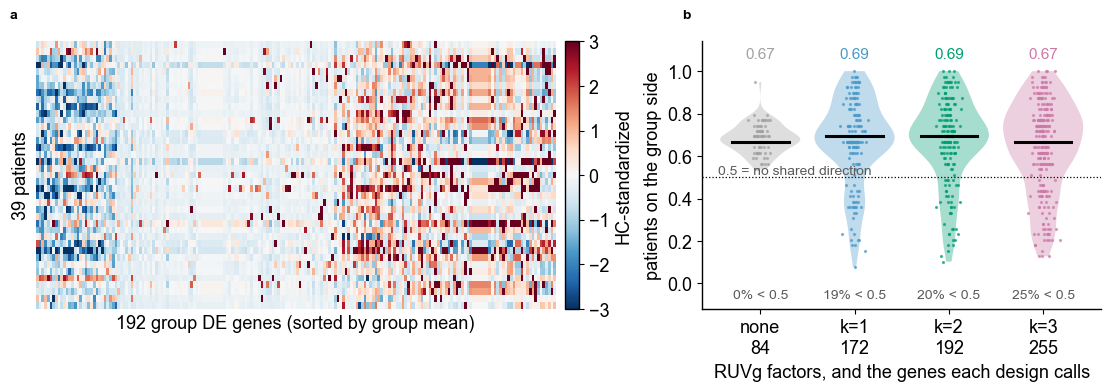

In [5]:
fig, direction_tbl = plot_direction(D, save_path=FIG / f'fig_group_direction__{COHORT}.png')
direction_tbl.round(3)


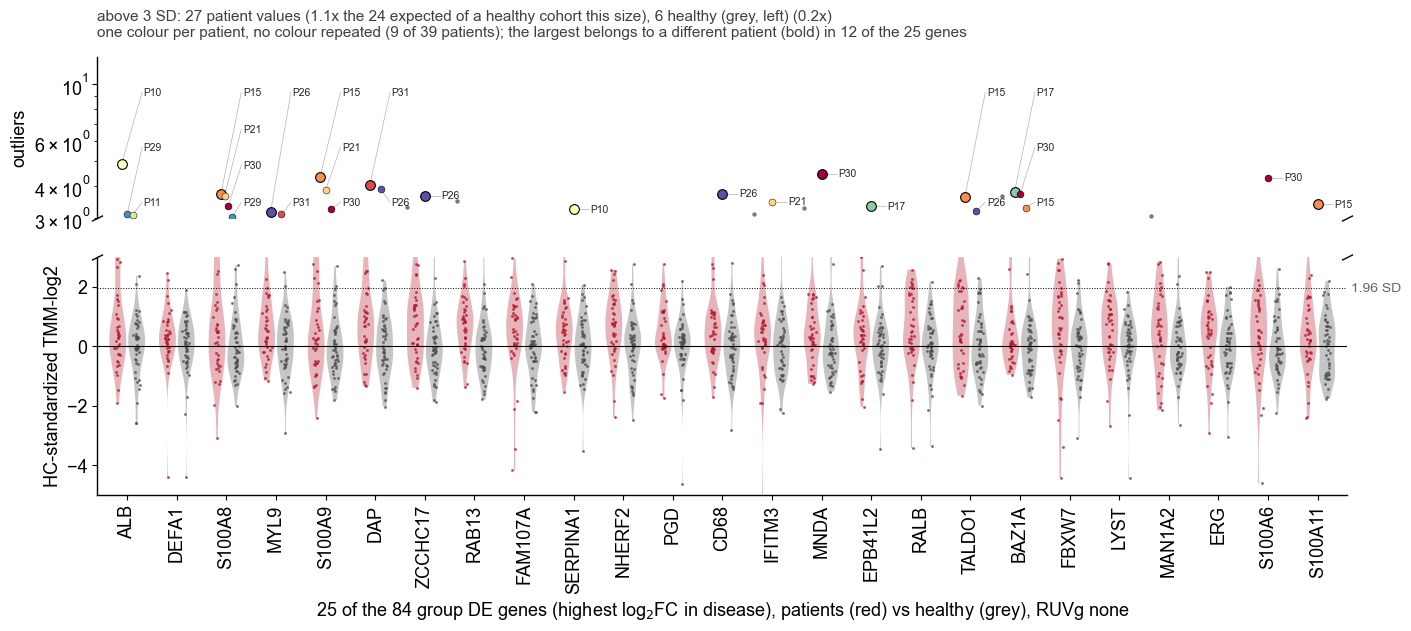

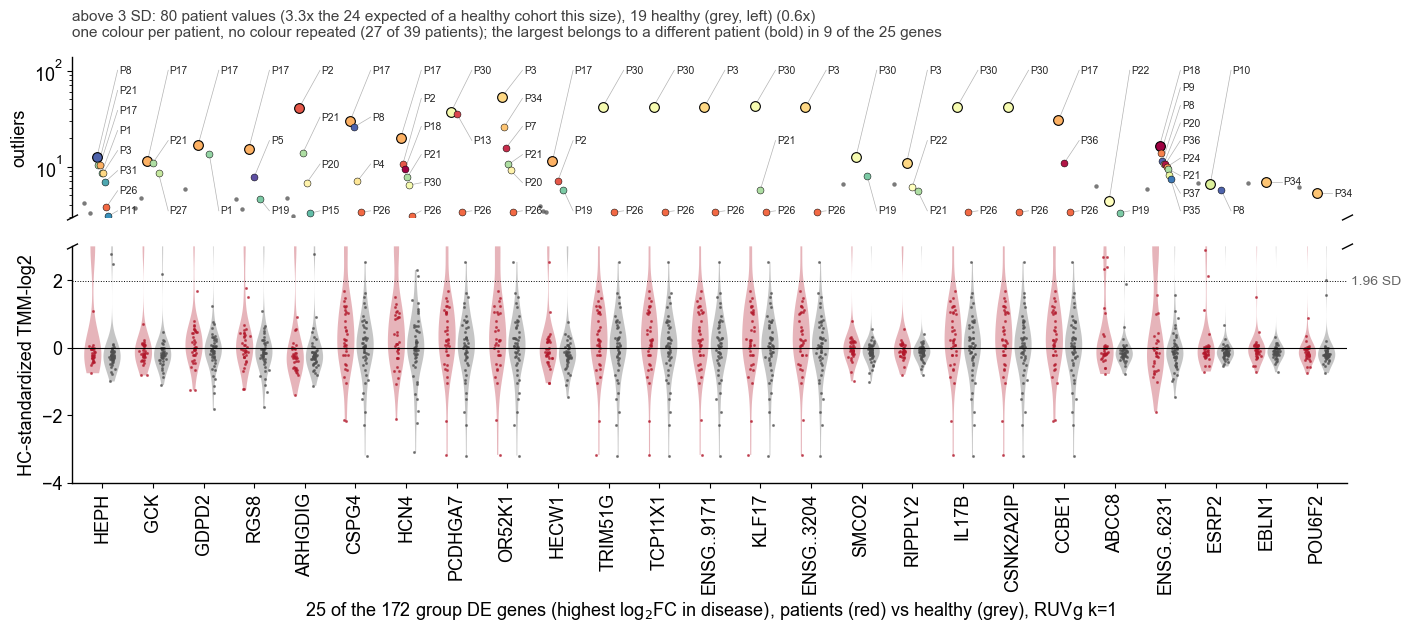

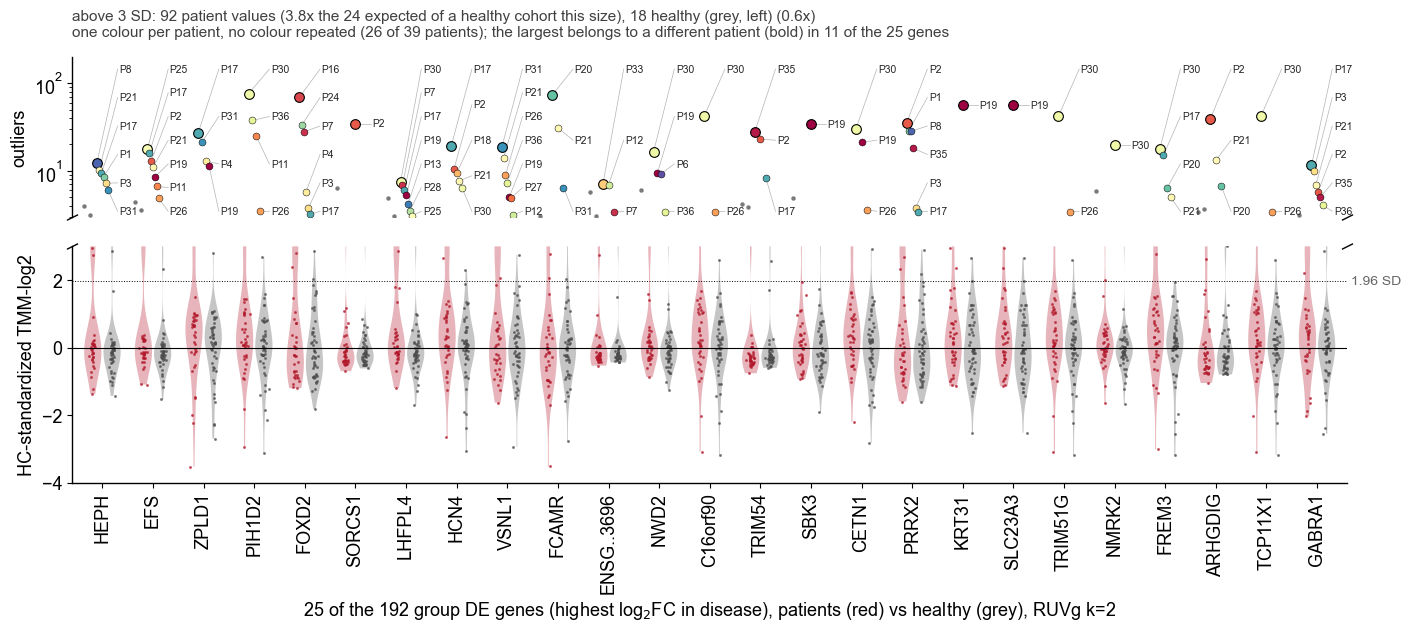

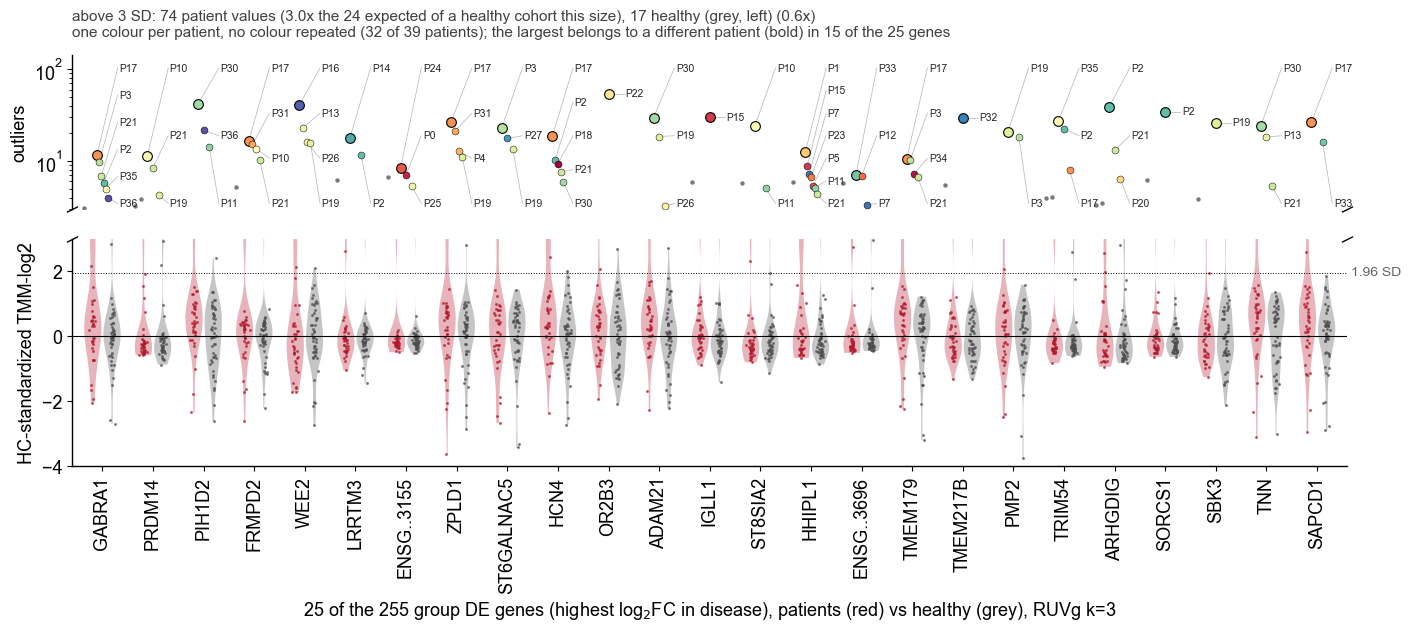

In [8]:
from analysis.plot_group_contrast import DESIGNS

for d in DESIGNS:
    plot_top_degs(D, save_path=FIG / f'fig_group_top_degs_violin__{d}__{COHORT}.png',
                  n_show=25, design=d, thr=3, rank='lfc')


In [7]:
outlier_decomposition(D, save_path=OUT / f'outlier_decomposition__{COHORT}.csv').round(4)


,design,thr,n_extreme,frac_extreme,patients_with_extreme,n_patients,genes_with_extreme,n_genes,loo_mean_shift_med,loo_mean_shift_max
0,ruvg_k2,6.0,159,0.0212,35,39,67,192,0.0258,0.1004
